# Phase 2: Composite Disruption Risk Scoring

Turns the Phase 1 signals (unexplained shocks, change points) into a
single, continuous 0-100 risk score per store/category/day, blended with
an oil-price volatility overlay as a macro proxy. This is what the
risk-adjusted inventory policy in Phase 3 will use to decide which
categories get extra safety stock.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt

from src.disruption_detection import load_panel, add_seasonal_baseline, compute_residuals, flag_shocks
from src.risk_scoring import compute_rolling_features, compute_composite_risk_score, latest_risk_ranking

pd.set_option('display.max_columns', None)

## Rebuild the Phase 1 signals

Same steps as the Phase 1 notebook, plus the change points saved from
that run.

In [2]:
panel = load_panel('../data/processed/daily_sales_by_store_family.csv')
panel = add_seasonal_baseline(panel, window_weeks=8)
panel = compute_residuals(panel)
shocks = flag_shocks(panel, z_window=90, z_thresh=3.0, min_periods=20)
changepoints = pd.read_csv('../reports/changepoints.csv', parse_dates=['date'])

print(shocks.shape, 'rows,', changepoints.shape[0], 'change points loaded')

(133096, 16) rows, 332 change points loaded


## Rolling risk features

Three signals, all trailing 90-day windows so nothing looks ahead:

- `shock_rate` — fraction of the last 90 days flagged as an unexplained shock
- `avg_abs_z` — average shock severity over the last 90 days
- `changepoint_rate` — fraction of the last 90 days that were a detected change point

Plus `oil_volatility`, a macro overlay: the rolling standard deviation of
daily oil price percent changes. It's the same value for every
store/category on a given date, so it shifts everyone's score together
during genuinely volatile macro periods, without drowning out the
store/category-specific signal.

In [3]:
features = compute_rolling_features(shocks, changepoints, panel, window_days=90, min_periods=30)
features[['date','store_nbr','family','shock_rate','avg_abs_z','changepoint_rate','oil_volatility']].tail()

,date,store_nbr,family,shock_rate,avg_abs_z,changepoint_rate,oil_volatility
133091,2017-08-11,51,PRODUCE,0.0,0.700279,0.0,0.013863
133092,2017-08-12,51,PRODUCE,0.0,0.669301,0.0,0.013863
133093,2017-08-13,51,PRODUCE,0.0,0.691864,0.0,0.013677
133094,2017-08-14,51,PRODUCE,0.0,0.699588,0.0,0.013922
133095,2017-08-15,51,PRODUCE,0.0,0.707004,0.0,0.013894


## Composite score

Each feature is percentile-ranked across the full dataset (robust to
skewed distributions like shock counts, unlike min-max scaling), then
combined with weights (35% shock rate, 25% average severity, 25%
change-point rate, 15% oil volatility) into one 0-100 score. The weights
favor the disruption-frequency signals over the macro overlay, since a
category's own shock history is a more direct risk signal than a shared
economic indicator.

In [4]:
scored = compute_composite_risk_score(features)
scored[['date','store_nbr','family','composite_risk_score']].tail()

,date,store_nbr,family,composite_risk_score
133091,2017-08-11,51,PRODUCE,37.130292
133092,2017-08-12,51,PRODUCE,34.915303
133093,2017-08-13,51,PRODUCE,36.448316
133094,2017-08-14,51,PRODUCE,37.104338
133095,2017-08-15,51,PRODUCE,37.682034


## Does it actually track known risk? A check against Phase 1's finding

Phase 1 found a real disruption for Store 51 / PRODUCE starting
January 2, 2014. If the composite score is doing its job, it should
spike right after that date and decay as the event rolls out of the
90-day trailing window.

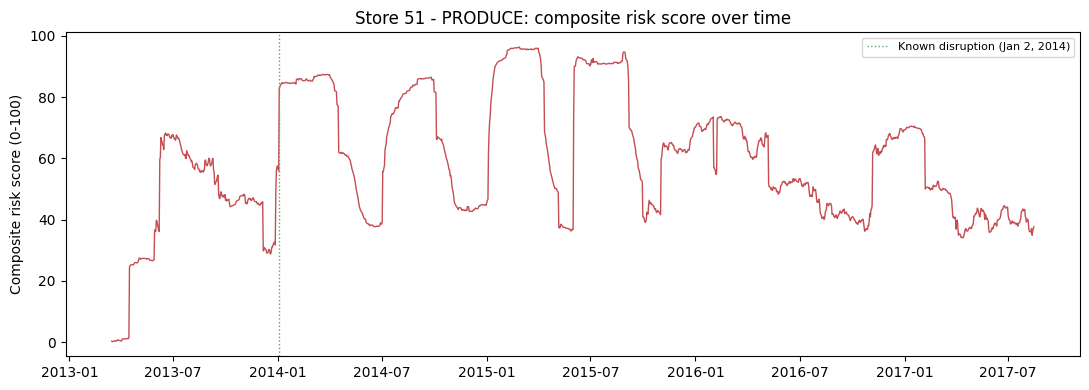

,date,composite_risk_score
132201,2015-02-27,96.368924
132200,2015-02-26,96.276174
132199,2015-02-25,96.219473
132198,2015-02-24,96.186277
132194,2015-02-20,96.136166


In [5]:
example = scored[(scored.store_nbr == 51) & (scored.family == 'PRODUCE')].sort_values('date')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(example['date'], example['composite_risk_score'], color='#C44E52', linewidth=1)
ax.axvline(pd.Timestamp('2014-01-02'), color='#55A868', linestyle=':', linewidth=1, label='Known disruption (Jan 2, 2014)')
ax.set_title('Store 51 - PRODUCE: composite risk score over time')
ax.set_ylabel('Composite risk score (0-100)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

example.sort_values('composite_risk_score', ascending=False)[['date','composite_risk_score']].head(5)

The score jumps from its baseline into the 80s-90s within two weeks of
the known event and stays elevated for roughly the following 90 days,
which is exactly the trailing window doing what it's supposed to —
confirms the scoring is picking up real signal, not just noise.

## Current risk ranking

One row per store/category, using the most recent date in the data —
this is the actionable view: which combinations are the highest risk to
stock right now.

In [6]:
ranking = latest_risk_ranking(scored)
ranking.head(10)

,store_nbr,family,date,shock_rate,avg_abs_z,changepoint_rate,oil_volatility,composite_risk_score
0,49,POULTRY,2017-08-15,0.011111,0.695414,0.0,0.013894,51.875953
1,50,MEATS,2017-08-15,0.000000,0.828815,0.0,0.013894,46.847092
2,51,MEATS,2017-08-15,0.000000,0.814691,0.0,0.013894,45.919618
3,8,CLEANING,2017-08-15,0.000000,0.788110,0.0,0.013894,44.042499
4,44,CLEANING,2017-08-15,0.000000,0.787770,0.0,0.013894,44.020720
5,49,CLEANING,2017-08-15,0.000000,0.783388,0.0,0.013894,43.703060
6,50,BREAD/BAKERY,2017-08-15,0.000000,0.764082,0.0,0.013894,42.238566
7,46,CLEANING,2017-08-15,0.000000,0.744903,0.0,0.013894,40.709127
8,50,PRODUCE,2017-08-15,0.000000,0.737794,0.0,0.013894,40.156017
9,50,CLEANING,2017-08-15,0.000000,0.737488,0.0,0.013894,40.131099


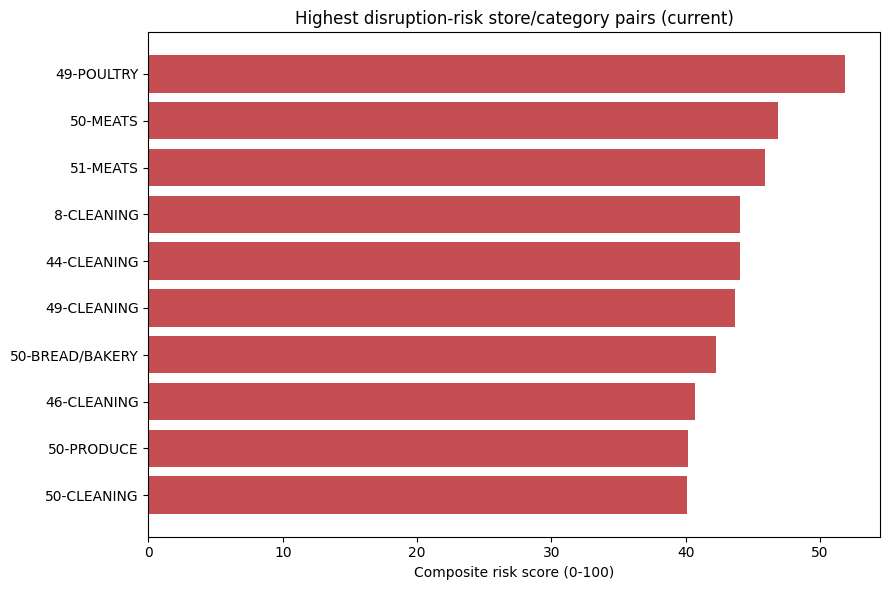

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
top10 = ranking.head(10).iloc[::-1]
labels = [f'{r.store_nbr}-{r.family}' for r in top10.itertuples()]
ax.barh(labels, top10['composite_risk_score'], color='#C44E52')
ax.set_xlabel('Composite risk score (0-100)')
ax.set_title('Highest disruption-risk store/category pairs (current)')
plt.tight_layout()
plt.savefig('../reports/figures/risk_ranking.png', dpi=130)
plt.show()

## Saving outputs

`composite_risk_history.csv` is the full daily time series (used by the
risk-adjusted inventory policy in Phase 3); `latest_risk_ranking.csv` is
the current-state view.

In [8]:
keep_cols = ['date','store_nbr','family','shock_rate','avg_abs_z','changepoint_rate',
             'oil_volatility','composite_risk_score']
scored[keep_cols].to_csv('../reports/composite_risk_history.csv', index=False)
ranking.to_csv('../reports/latest_risk_ranking.csv', index=False)
print('saved')

saved
